In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats
from scipy.special import logit

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
#df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
#               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
#               "EV", "Barrel%", "HardHit%"]]
df = raw_data[["Season", "Name", "Team", "Age", "PA", "HR",
               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", 
               "K%", "EV", "HardHit%"]]

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2018_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2018_2025.csv", index=False)

In [3]:
print(f"Total rows: {len(df)}")
print(f"Total players: {df['Name'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique().tolist())}")

Total rows: 946
Total players: 377
Seasons: [2018, 2019, 2021, 2022, 2023, 2024, 2025]


In [9]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year HR target (was AVG_next) ---
df['HR_next'] = df.groupby('Name')['HR'].shift(-1)  

# --- Split into training and prediction sets ---
model_df = df[df['HR_next'].notna()].copy()
model_df = model_df[model_df['Season'] != 2024].copy()
df_2024 = df[df['Season'] == 2024].copy()

# --- Define features and target ---
model_df['Age2'] = model_df['Age'] ** 2
df_2024['Age2'] = df_2024['Age'] ** 2

features = ["Age", "Age2", "HR", "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA",
            "K%", "EV", "HardHit%"]
target = 'HR_next'

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features])
X_2024 = scaler_X.transform(df_2024[features])

# --- Set Target ---
y = model_df[target].values.astype(int) #not standardized, integer values

print(f"Seasons in model_df: {sorted(model_df['Season'].unique().tolist())}")
print(f"Any nulls in X: {np.isnan(X).any()}")
print(f"Any nulls in X_2024: {np.isnan(X_2024).any()}")
print(f"Training rows: {len(model_df)}")
print(f"Players to predict: {len(df_2024)}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")
print(model_df[["Season", "Name", 'Age', "HR", "HR_next"]].head(10))

Seasons in model_df: [2018, 2019, 2021, 2022, 2023]
Any nulls in X: False
Any nulls in X_2024: False
Training rows: 481
Players to predict: 129
y mean: 23.096, y std: 10.134
    Season             Name  Age  HR  HR_next
2     2021      Aaron Judge   29  39     62.0
3     2022      Aaron Judge   30  62     58.0
8     2019     Adam Frazier   27  10      5.0
9     2021     Adam Frazier   29   5      3.0
11    2018       Adam Jones   32  15     16.0
14    2023  Adley Rutschman   25  20     19.0
16    2021    Adolis Garcia   28  31     27.0
17    2022    Adolis Garcia   29  27     39.0
18    2023    Adolis Garcia   30  39     25.0
24    2022        Alec Bohm   25  13     20.0


In [10]:
#Check Correlation between terms
print(pd.DataFrame(X, columns=features).corr())
#Going to use LOOCV to find best set of features

               Age      Age2        HR       AVG       OBP       SLG  \
Age       1.000000  0.996538 -0.012724 -0.022894  0.041878 -0.053257   
Age2      0.996538  1.000000 -0.012473 -0.019415  0.045903 -0.051385   
HR       -0.012724 -0.012473  1.000000  0.123759  0.314449  0.838812   
AVG      -0.022894 -0.019415  0.123759  1.000000  0.684381  0.570802   
OBP       0.041878  0.045903  0.314449  0.684381  1.000000  0.608715   
SLG      -0.053257 -0.051385  0.838812  0.570802  0.608715  1.000000   
OPS      -0.023883 -0.021068  0.731522  0.669222  0.811877  0.957380   
xBA      -0.001650  0.003970  0.176939  0.797608  0.609386  0.511697   
xwOBA     0.047199  0.052747  0.658898  0.426900  0.738085  0.760206   
K%       -0.119184 -0.120487  0.307742 -0.441661 -0.278450  0.068310   
EV       -0.008031  0.002857  0.593748  0.122118  0.302686  0.550752   
HardHit%  0.022616  0.031186  0.578619  0.089413  0.258381  0.510792   

               OPS       xBA     xwOBA        K%        EV  Har

In [11]:
with pm.Model(coords={"features": features}) as model:

    # --- Create Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)

    # --- Create Model ---
    alpha = pm.Normal('alpha', mu=3, sigma=1)
    betas = pm.Normal('betas', mu=0, sigma=0.5, dims="features")
    alpha_nb = pm.HalfNormal('alpha_nb', sigma=5)  # overdispersion parameter
    
    # --- Log-Linear Model ---
    mu = pm.Deterministic('mu', pm.math.exp(alpha + (X_data * betas).sum(axis=1)))

    # --- Likelihood ---
    y_obs = pm.NegativeBinomial('y_obs', mu=mu, alpha=alpha_nb, observed=y_data)

    # --- Sample ---
    trace = pm.sample(2000, tune=1500, chains=4, target_accept=0.85, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, alpha_nb]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 415 seconds.


In [12]:
with model:
    prior = pm.sample_prior_predictive(500)
    

Sampling: [alpha, alpha_nb, betas, y_obs]


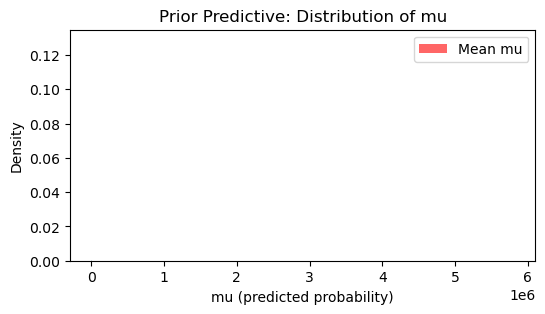

In [13]:
# mu has shape (chains, draws, n_observations) — flatten draws
mu_samples = prior.prior["mu"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
# Plot a random subset of 100 draw curves as histograms overlaid
for i in np.random.choice(mu_samples.shape[0], 100, replace=False):
    plt.hist(mu_samples[i], bins=30, alpha=0.02, color="steelblue", density=True)

# Also plot the mean across all draws
plt.hist(mu_samples.mean(axis=0), bins=30, alpha=0.6, color="red", density=True, label="Mean mu")
plt.xlabel("mu (predicted probability)")
plt.ylabel("Density")
plt.title("Prior Predictive: Distribution of mu")
plt.legend()
plt.show()

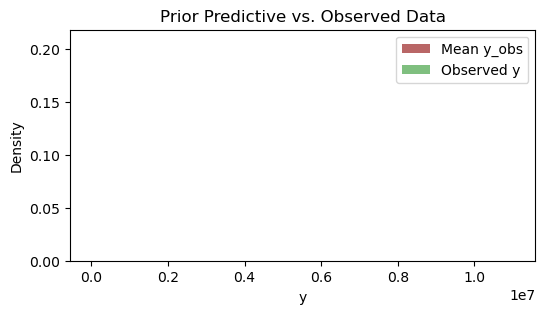

In [14]:
# y_obs lives in prior_predictive, shape (chains, draws, n_observations)
y_prior = prior.prior_predictive["y_obs"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
for i in np.random.choice(y_prior.shape[0], 100, replace=False):
    plt.hist(y_prior[i], bins=30, alpha=0.02, color="darkorange", density=True)

plt.hist(y_prior.mean(axis=0), bins=30, alpha=0.6, color="darkred", density=True, label="Mean y_obs")

# Overlay observed y for comparison
plt.hist(y, bins=30, alpha=0.5, color="green", density=True, label="Observed y")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Prior Predictive vs. Observed Data")
plt.legend()
plt.show()

In [15]:
print(f"Prior mu mean:        {mu_samples.mean():.3f}")
print(f"Prior y_obs mean:     {y_prior.mean():.3f}")
print(f"Observed y mean:      {y.mean():.3f}")

Prior mu mean:        2177.356
Prior y_obs mean:     1856.074
Observed y mean:      23.096


In [16]:
az.summary(trace, var_names=['alpha', 'betas', 'alpha_nb'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.099,0.017,3.065,3.128,0.000,0.000,9360.0,5531.0,1.0
betas[Age],0.105,0.179,-0.227,0.443,0.002,0.002,7016.0,5406.0,1.0
betas[Age2],-0.146,0.180,-0.484,0.192,0.002,0.002,6996.0,5333.0,1.0
betas[HR],0.058,0.052,-0.036,0.163,0.001,0.001,8540.0,5097.0,1.0
betas[AVG],-0.003,0.065,-0.122,0.119,0.001,0.001,5401.0,5466.0,1.0
betas[OBP],-0.140,0.148,-0.414,0.131,0.002,0.002,4390.0,4866.0,1.0
betas[SLG],0.042,0.291,-0.526,0.559,0.004,0.003,4361.0,4896.0,1.0
betas[OPS],0.059,0.390,-0.694,0.753,0.006,0.005,4561.0,4892.0,1.0
betas[xBA],-0.188,0.064,-0.305,-0.066,0.001,0.001,4911.0,4636.0,1.0
betas[xwOBA],0.265,0.080,0.114,0.414,0.001,0.001,5177.0,5612.0,1.0


In [17]:
for i, feature in enumerate(features):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    contains_zero = row['hdi_3%'] < 0 < row['hdi_97%']
    zero_msg = " ⚠️ HDI contains zero" if contains_zero else ""
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]{zero_msg}")

Age           mean=+0.1050  hdi=[-0.2270, +0.4430] ⚠️ HDI contains zero
Age2          mean=-0.1460  hdi=[-0.4840, +0.1920] ⚠️ HDI contains zero
HR            mean=+0.0580  hdi=[-0.0360, +0.1630] ⚠️ HDI contains zero
AVG           mean=-0.0030  hdi=[-0.1220, +0.1190] ⚠️ HDI contains zero
OBP           mean=-0.1400  hdi=[-0.4140, +0.1310] ⚠️ HDI contains zero
SLG           mean=+0.0420  hdi=[-0.5260, +0.5590] ⚠️ HDI contains zero
OPS           mean=+0.0590  hdi=[-0.6940, +0.7530] ⚠️ HDI contains zero
xBA           mean=-0.1880  hdi=[-0.3050, -0.0660]
xwOBA         mean=+0.2650  hdi=[+0.1140, +0.4140]
K%            mean=-0.0390  hdi=[-0.0920, +0.0100] ⚠️ HDI contains zero
EV            mean=+0.0790  hdi=[-0.0170, +0.1760] ⚠️ HDI contains zero
HardHit%      mean=-0.0080  hdi=[-0.1140, +0.0940] ⚠️ HDI contains zero


In [18]:
with model:
    pm.set_data({
        'X_data': X_2024,
        'y_data': np.full(len(df_2024), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2024.posterior_predictive['y_obs'].values.reshape(-1, len(df_2024))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2024['predicted_HR'] = pred_samples.mean(axis=0)
df_2024['pred_hdi_low'] = hdi_vals[:, 0]
df_2024['pred_hdi_high'] = hdi_vals[:, 1]

df_display = df_2024.dropna(subset=['HR_next'])

df_display[['Name', 'HR', 'predicted_HR', 'HR_next', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('HR', ascending=False)\
      .head(20)

TypeError: ('Vector(int32, shape=(?,)) cannot store a value of dtype float64 without risking loss of precision. If you do not mind this loss, you can: 1) explicitly cast your data to int32, or 2) set "allow_input_downcast=True" when calling "function". Value: "array([0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111,\n       0.111, 0.111, 0.111, 0

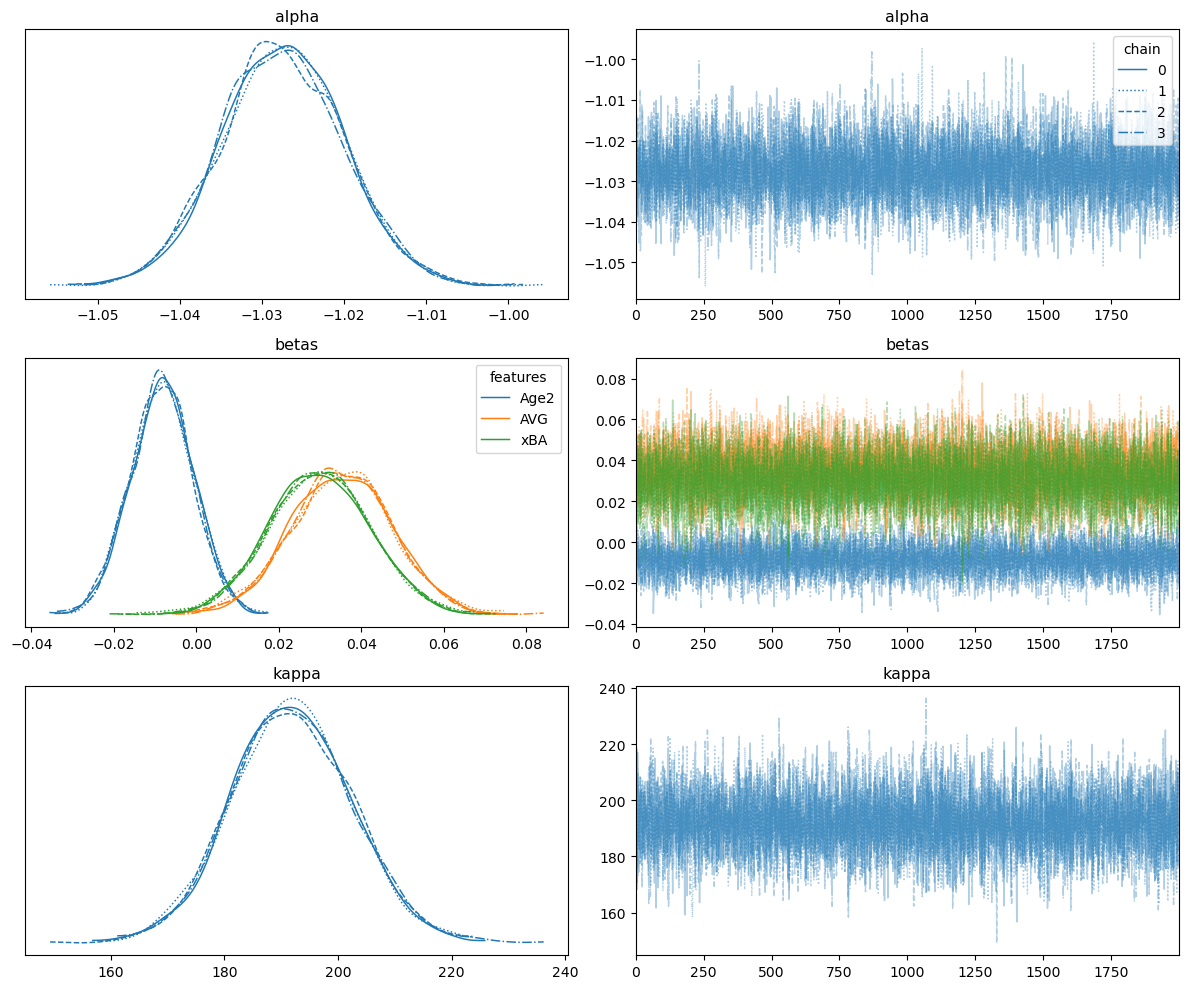

In [ ]:
az.plot_trace(trace, var_names=['alpha', 'betas', 'alpha_nb'], 
              figsize=(12, 10), legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# --- Drop players without a known 2025 AVG ---
eval_df = df_2024.dropna(subset=['HR_next']).copy()
print(f"Players with known 2025 HR Total: {len(eval_df)} / {len(df_2024)}")

# --- RMSE ---
rmse = root_mean_squared_error(eval_df['HR_next'], eval_df['HR_next'])
print(f"RMSE: {rmse:.4f}") # on same scale as AVG: off by ~0.0216 units on average

# --- Correlation ---
corr, pval = stats.pearsonr(eval_df['HR_next'], eval_df['predicted_HR'])
print(f"Pearson correlation: {corr:.4f}")
print(f"R^2: {corr**2:.4f}") # explains x% of variance
print(f"P-value: {pval:.4f}")

# --- Mean bias ---
bias = (eval_df['predicted_HR'] - eval_df['HR_next']).mean()
print(f"Mean bias: {bias:+.4f}") # whether the model over or under predicts (skew)

# --- Coverage ---
coverage = ((eval_df['HR_next'] >= eval_df['pred_hdi_low']) & 
            (eval_df['HR_next'] <= eval_df['pred_hdi_high'])).mean()
print(f"HDI coverage: {coverage:.1%}")

Players with known 2025 AVG: 88 / 129
RMSE: 0.0216
Pearson correlation: 0.4760
R^2: 0.2266
P-value: 0.0000
Mean bias: +0.0020
HDI coverage: 97.7%


Sampling: [y_obs]


Output()

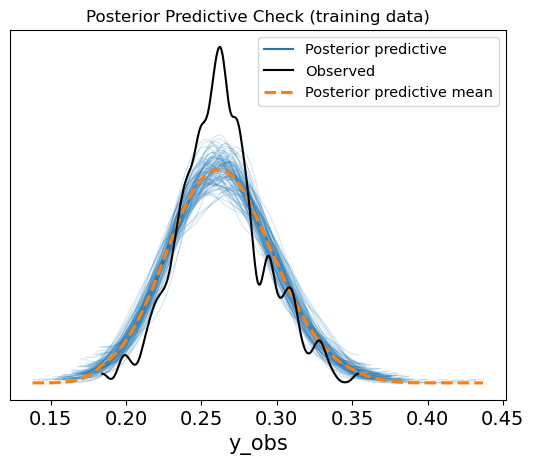

In [41]:
# regenerate ppc on training data
with model:
    pm.set_data({'X_data': X, 'y_data': y})
    ppc_train = pm.sample_posterior_predictive(trace)

# now plot against real observed values
az.plot_ppc(ppc_train, num_pp_samples=100)
plt.title('Posterior Predictive Check (training data)')
plt.show()

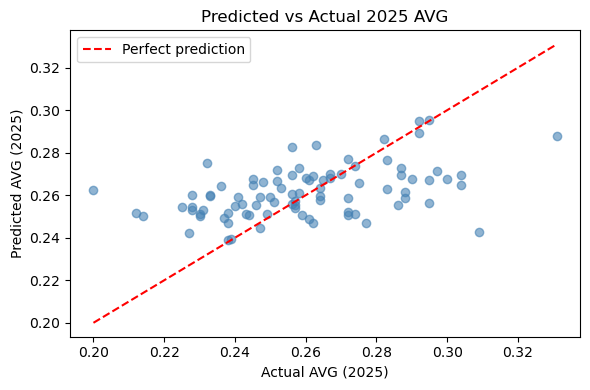

In [ ]:
# --- Plot 1: Predicted vs Actual 2025 HR ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df_2024['HR_next'], df_2024['predicted_HR'], alpha=0.6, color='steelblue')

min_val = min(df_2024['HR_next'].min(), df_2024['predicted_HR'].min())
max_val = max(df_2024['HR_next'].max(), df_2024['predicted_HR'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual HR (2025)')
ax.set_ylabel('Predicted HR (2025)')
ax.set_title('Predicted vs Actual 2025 HR')
ax.legend()

plt.tight_layout()
plt.show()

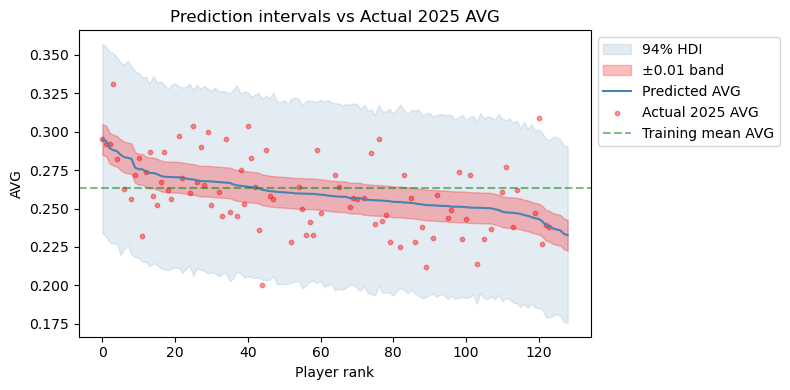

In [ ]:
# --- Plot 2: Prediction intervals vs Actual 2025 HR ---
fig, ax = plt.subplots(figsize=(8, 4))

df_sorted = df_2024.sort_values('predicted_HR', ascending=False).reset_index(drop=True)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['pred_hdi_low'],
    df_sorted['pred_hdi_high'],
    alpha=0.15, color='steelblue', label='94% HDI'
)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['predicted_HR'] - 0.01,
    df_sorted['predicted_HR'] + 0.01,
    alpha=0.25, color='red', label='±0.01 band'
)

ax.plot(range(len(df_sorted)), df_sorted['predicted_HR'],
        color='steelblue', linewidth=1.5, label='Predicted HR')
ax.scatter(range(len(df_sorted)), df_sorted['HR_next'],
           color='red', s=10, alpha=0.4, label='Actual 2025 HR')

ax.axhline(y.mean(), color='green', linestyle='--', alpha=0.5, label='Training mean HR')

ax.set_xlabel('Player rank')
ax.set_ylabel('HR')
ax.set_title('Prediction intervals vs Actual 2025 HR')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
n_total = len(df_2024)

for band in [0.01, 0.025, 0.05]:
    n_within = ((df_2024['HR_next'] >= df_2024['predicted_HR'] - band) &
                (df_2024['HR_next'] <= df_2024['predicted_HR'] + band)).sum()
    print(f"{n_within}/{n_total} predictions within ±{band} ({n_within/n_total:.1%})")

35/129 predictions within ±0.01 (27.1%)
64/129 predictions within ±0.025 (49.6%)
86/129 predictions within ±0.05 (66.7%)


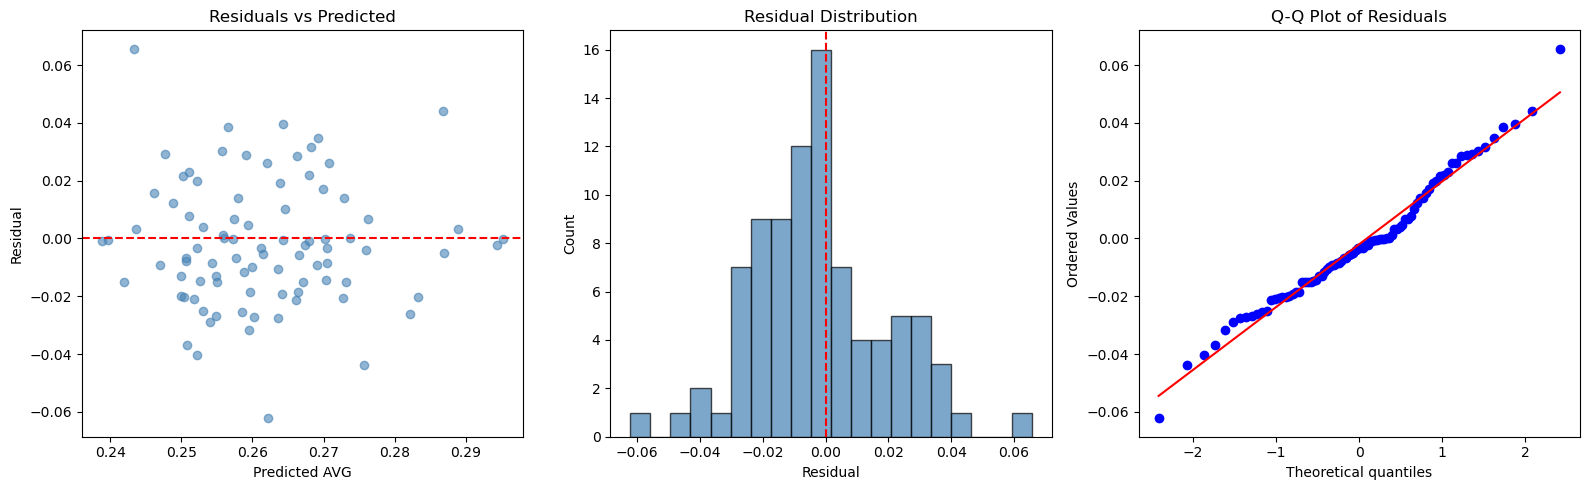

In [ ]:
residuals = eval_df['HR_next'].values - eval_df['predicted_HR'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Residuals vs Predicted ---
ax = axes[0]
ax.scatter(eval_df['predicted_HR'], residuals, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted HR')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# --- Residuals Histogram ---
ax = axes[1]
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

# --- Q-Q Plot ---
ax = axes[2]
stats.probplot(residuals, plot=ax)
ax.set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [ ]:
with model:
    pm.set_data({
        'X_data': X_2024,
        'y_data': np.full(len(df_2024), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2024.posterior_predictive['y_obs'].values.reshape(-1, len(df_2024))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2024['predicted_HR'] = pred_samples.mean(axis=0)
df_2024['pred_hdi_low'] = hdi_vals[:, 0]
df_2024['pred_hdi_high'] = hdi_vals[:, 1]

df_2024[['Name', 'HR', 'predicted_HR', 'HR_next', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_HR', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 129)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_23096\3062125380.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Name,AVG,xBA,predicted_AVG,AVG_next,pred_hdi_low,pred_hdi_high
100,Bobby Witt Jr.,0.332,0.309,0.295540,0.295,0.231675,0.357015
883,Vladimir Guerrero Jr.,0.323,0.317,0.294865,0.292,0.231912,0.355555
567,Luis Arraez,0.314,0.310,0.289117,0.292,0.225028,0.347494
4,Aaron Judge,0.322,0.305,0.287983,0.331,0.226469,0.351053
801,Shohei Ohtani,0.310,0.310,0.286616,0.282,0.225785,0.349354
936,Yordan Alvarez,0.308,0.300,0.284862,NaN,0.226824,0.349614
364,Jackson Merrill,0.292,0.300,0.283581,NaN,0.223023,0.343875
490,Juan Soto,0.288,0.311,0.283496,0.263,0.224707,0.347403
917,Yainer Diaz,0.299,0.297,0.282568,0.256,0.220577,0.344877
817,Steven Kwan,0.292,0.283,0.277019,0.272,0.218987,0.338495
